## Projet de Scoring Risque Crédit (German Credit)




In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.linear_model import LogisticRegression
from ucimlrepo import fetch_ucirepo
import xgboost as xgb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
import statsmodels.api as sm
import warnings
warnings.filterwarnings("ignore")

# Charger le dataset German Credit
statlog_german_credit_data = fetch_ucirepo(id=144)
X = statlog_german_credit_data.data.features
y = statlog_german_credit_data.data.targets['class'].map({1: 0, 2: 1})

# Créer dataframe unique final
print(f"Dataset shape: {df.shape}")
print("\nPremières lignes:")
df.head()

Dataset shape: (1000, 21)

Premières lignes:


,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account_bonds,present_employment_since,installment_rate_pct,personal_status_sex,other_debtors_guarantors,...,property,age_years,other_installment_plans,housing,existing_credits_count,job_type,people_liable_maintenance,telephone,foreign_worker,credit_risk
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,0
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,1
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,0
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,0
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,1


In [41]:
# Mappage des colonnes avec descriptions métier
column_mapping = {
    'Attribute1': 'checking_account_status',
    'Attribute2': 'duration_months',
    'Attribute3': 'credit_history',
    'Attribute4': 'purpose',
    'Attribute5': 'credit_amount',
    'Attribute6': 'savings_account_bonds',
    'Attribute7': 'present_employment_since',
    'Attribute8': 'installment_rate_pct',
    'Attribute9': 'personal_status_sex',
    'Attribute10': 'other_debtors_guarantors',
    'Attribute11': 'present_residence_since_years',
    'Attribute12': 'property',
    'Attribute13': 'age_years',
    'Attribute14': 'other_installment_plans',
    'Attribute15': 'housing',
    'Attribute16': 'existing_credits_count',
    'Attribute17': 'job_type',
    'Attribute18': 'people_liable_maintenance',
    'Attribute19': 'telephone',
    'Attribute20': 'foreign_worker',
    'class': 'credit_risk'
}

df.rename(columns=column_mapping, inplace=True)

# Afficher les catégories et numériques
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"Colonnes catégorielles ({len(categorical_cols)}): {categorical_cols}")
print(f"Colonnes numériques ({len(numerical_cols)}): {numerical_cols}")
print(f"\nDistribution cible - 0 (Good): {(df['credit_risk']==0).sum()}, 1 (Bad): {(df['credit_risk']==1).sum()}")

Colonnes catégorielles (13): ['checking_account_status', 'credit_history', 'purpose', 'savings_account_bonds', 'present_employment_since', 'personal_status_sex', 'other_debtors_guarantors', 'property', 'other_installment_plans', 'housing', 'job_type', 'telephone', 'foreign_worker']
Colonnes numériques (8): ['duration_months', 'credit_amount', 'installment_rate_pct', 'present_residence_since_years', 'age_years', 'existing_credits_count', 'people_liable_maintenance', 'credit_risk']

Distribution cible - 0 (Good): 700, 1 (Bad): 300


In [42]:
# Mappage des catégories en langage métier
mappings = {
    'checking_account_status': {
        'A11': '< 0 DM',
        'A12': '0-200 DM',
        'A13': '>= 200 DM / salary',
        'A14': 'No account'
    },
    'credit_history': {
        'A30': 'No credits / all paid',
        'A31': 'All credits paid here',
        'A32': 'Paid duly till now',
        'A33': 'Past delays',
        'A34': 'Critical account'
    },
    'purpose': {
        'A40': 'Car (new)',
        'A41': 'Car (used)',
        'A42': 'Furniture/equipment',
        'A43': 'Radio/TV',
        'A44': 'Appliances',
        'A45': 'Repairs',
        'A46': 'Education',
        'A48': 'Retraining',
        'A49': 'Business',
        'A410': 'Others'
    },
    'savings_account_bonds': {
        'A61': '< 100 DM',
        'A62': '100-500 DM',
        'A63': '500-1000 DM',
        'A64': '>= 1000 DM',
        'A65': 'No savings'
    },
    'present_employment_since': {
        'A71': 'Unemployed',
        'A72': '< 1 year',
        'A73': '1-4 years',
        'A74': '4-7 years',
        'A75': '>= 7 years'
    },
    'personal_status_sex': {
        'A91': 'Male: divorced/separated',
        'A92': 'Female: divorced/separated',
        'A93': 'Male: single',
        'A94': 'Male: married',
        'A95': 'Female: single'
    },
    'other_debtors_guarantors': {
        'A101': 'None',
        'A102': 'Co-applicant',
        'A103': 'Guarantor'
    },
    'property': {
        'A121': 'Real estate',
        'A122': 'Savings/insurance',
        'A123': 'Car/other',
        'A124': 'No property'
    },
    'other_installment_plans': {
        'A141': 'Bank',
        'A142': 'Stores',
        'A143': 'None'
    },
    'housing': {
        'A151': 'Rent',
        'A152': 'Own',
        'A153': 'Free'
    },
    'job_type': {
        'A171': 'Unemployed/unskilled',
        'A172': 'Unskilled',
        'A173': 'Skilled employee',
        'A174': 'Management'
    },
    'telephone': {
        'A191': 'No',
        'A192': 'Yes'
    },
    'foreign_worker': {
        'A201': 'Yes',
        'A202': 'No'
    }
}

for col, mapping in mappings.items():
    if col in df.columns:
        df[col] = df[col].map(mapping)

print("Données transformées avec succès")

Données transformées avec succès


In [43]:
# Analyse exploratoire: Vérifier les valeurs manquantes
print("Valeurs manquantes:")
print(df.isnull().sum().sum())
print("\nStatistiques numériques:")
df.describe()

Valeurs manquantes:
0

Statistiques numériques:


,duration_months,credit_amount,installment_rate_pct,present_residence_since_years,age_years,existing_credits_count,people_liable_maintenance,credit_risk
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000,0.300000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086,0.458487
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000,0.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000,0.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000,0.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000,1.000000


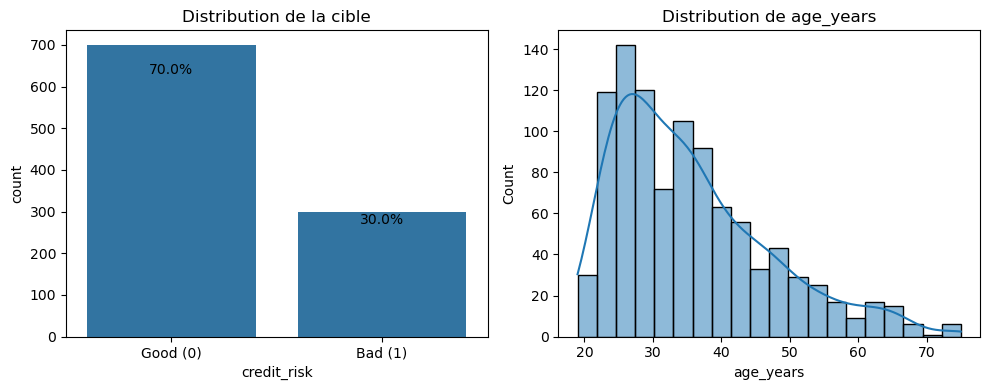

In [44]:
# ============ EXPLORATION DE LA CIBLE ET DES VARIABLES NUMÉRIQUES ============

# Distribution de la cible (Good vs Bad)
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

sns.countplot(x='credit_risk', data=df, ax=ax[0])
ax[0].set_title('Distribution de la cible')
ax[0].set_xticklabels(['Good (0)', 'Bad (1)'])

# Répartition en pourcentage
target_counts = df['credit_risk'].value_counts(normalize=True) * 100
for i, (cls, pct) in enumerate(target_counts.items()):
    ax[0].text(i, target_counts.iloc[i] / 100 * df.shape[0] * 0.9, f"{pct:.1f}%", ha='center', color='black')

# Distribution de quelques variables numériques clés
num_vars_plot = ['age_years', 'credit_amount', 'duration_months']
for var in num_vars_plot:
    if var in df.columns:
        sns.histplot(df[var], bins=20, kde=True, ax=ax[1])
        ax[1].set_title(f'Distribution de {var}')
        break

plt.tight_layout()
plt.show()


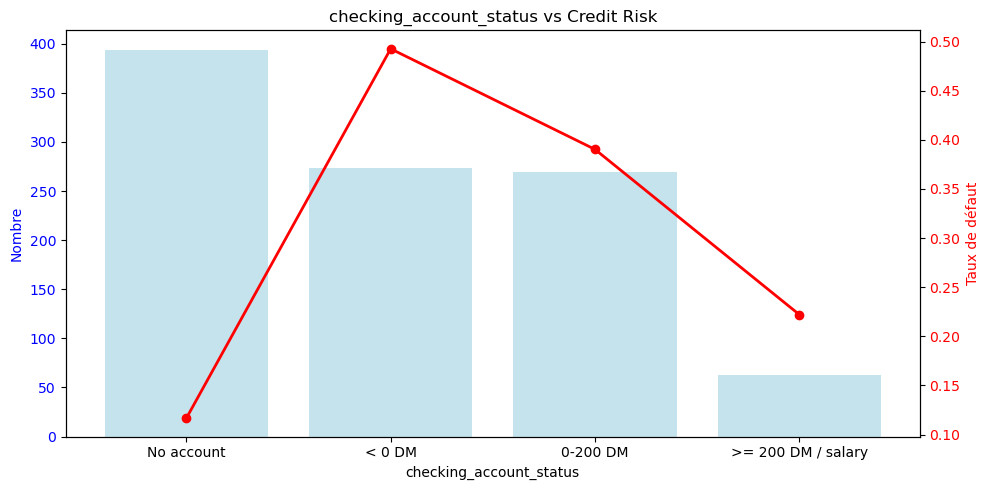

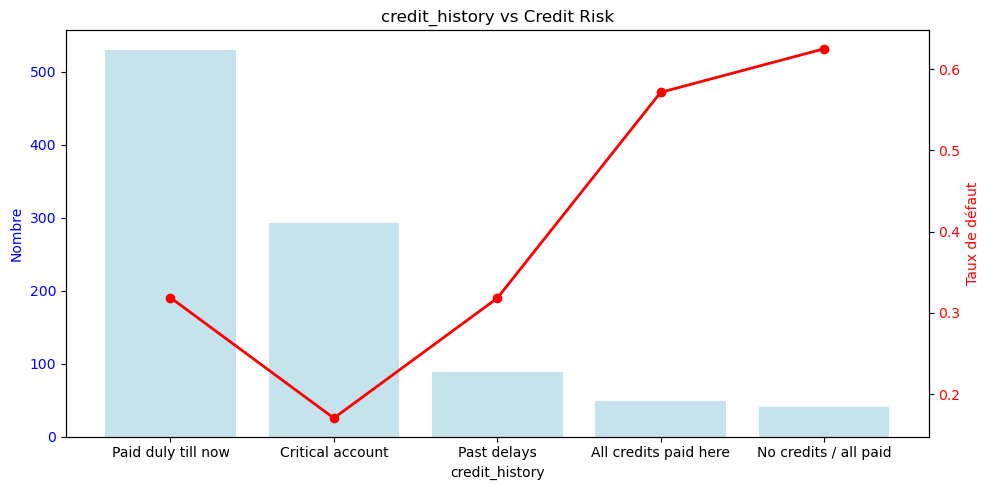

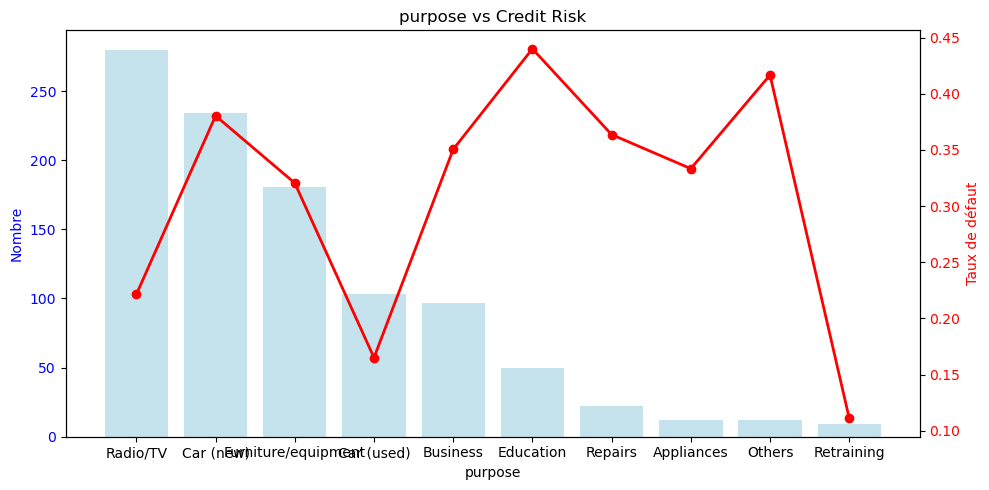

In [45]:
# Visualisation: Taux de défaut par variable catégorique
def plot_categorical_risk(df, col):
    counts = df[col].value_counts()
    bad_rate = df.groupby(col)['credit_risk'].mean().reindex(counts.index)
    
    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax2 = ax1.twinx()
    
    ax1.bar(counts.index, counts.values, color='lightblue', alpha=0.7, label='Count')
    ax2.plot(counts.index, bad_rate.values, color='red', marker='o', linewidth=2, label='Bad Rate')
    
    ax1.set_xlabel(col)
    ax1.set_ylabel('Nombre', color='blue')
    ax2.set_ylabel('Taux de défaut', color='red')
    ax1.tick_params(axis='y', labelcolor='blue')
    ax2.tick_params(axis='y', labelcolor='red')
    plt.title(f'{col} vs Credit Risk')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# Visualiser les variables principales
for var in ['checking_account_status', 'credit_history', 'purpose']:
    plot_categorical_risk(df, var)

In [46]:
# ============ PRÉPARATION DES DONNÉES ============
X = df.drop('credit_risk', axis=1)
y = df['credit_risk']

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Target Encoding SANS LISSAGE (sur train uniquement)
for col in categorical_cols:
    risk_map = y_train.groupby(X_train[col]).mean()
    X_train[f"{col}_risk"] = X_train[col].map(risk_map)
    X_test[f"{col}_risk"] = X_test[col].map(risk_map)
    X_test[f"{col}_risk"].fillna(y_train.mean(), inplace=True)

# Supprimer les colonnes catégorielles originales
X_train = X_train.drop(categorical_cols, axis=1)
X_test = X_test.drop(categorical_cols, axis=1)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (800, 20), Test shape: (200, 20)


In [47]:
# ============ MODÈLE 1: LOGISTIC REGRESSION ============
X_lr = sm.add_constant(X_train)
X_test_lr = sm.add_constant(X_test)

model_lr = sm.Logit(y_train, X_lr)
result_lr = model_lr.fit(disp=0)

print("=" * 60)
print("LOGISTIC REGRESSION")
print("=" * 60)
print(result_lr.summary())

LOGISTIC REGRESSION
                           Logit Regression Results                           
Dep. Variable:            credit_risk   No. Observations:                  800
Model:                          Logit   Df Residuals:                      779
Method:                           MLE   Df Model:                           20
Date:                Mon, 15 Dec 2025   Pseudo R-squ.:                  0.2472
Time:                        18:00:13   Log-Likelihood:                -367.89
converged:                       True   LL-Null:                       -488.69
Covariance Type:            nonrobust   LLR p-value:                 5.590e-40
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const                           -17.7173      2.894     -6.122      0.000     -23.389     -12.045
duration_months                   0.0234      0.010   

XGBOOST - AUC: 0.799
              precision    recall  f1-score   support

        Good       0.82      0.89      0.85       140
         Bad       0.67      0.55      0.61        60

    accuracy                           0.79       200
   macro avg       0.75      0.72      0.73       200
weighted avg       0.78      0.79      0.78       200

Coût métier: 151 (Faux 'Good': 27, Faux 'Bad': 16)


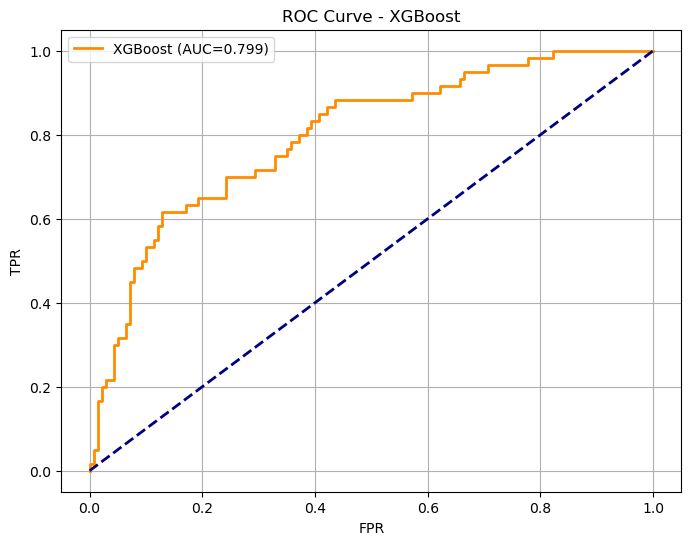

In [48]:
# ============ MODÈLE 2: XGBOOST ============
model_xgb = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)
model_xgb.fit(X_train, y_train)

y_pred_xgb = model_xgb.predict(X_test)
y_proba_xgb = model_xgb.predict_proba(X_test)[:, 1]

auc_xgb = roc_auc_score(y_test, y_proba_xgb)
print("=" * 60)
print(f"XGBOOST - AUC: {auc_xgb:.3f}")
print("=" * 60)
print(classification_report(y_test, y_pred_xgb, target_names=["Good", "Bad"]))

# Coût métier
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_xgb).ravel()
cost_xgb = 5 * fn + 1 * fp
print(f"Coût métier: {cost_xgb} (Faux 'Good': {fn}, Faux 'Bad': {fp})")

# ROC Curve
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)
plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb, tpr_xgb, color='darkorange', lw=2, label=f'XGBoost (AUC={auc_xgb:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC Curve - XGBoost')
plt.legend()
plt.grid(True)
plt.show()

DEEP LEARNING (MLP)
AUC: 0.803

Classification Report:
              precision    recall  f1-score   support

        Good       0.82      0.84      0.83       140
         Bad       0.61      0.57      0.59        60

    accuracy                           0.76       200
   macro avg       0.71      0.70      0.71       200
weighted avg       0.76      0.76      0.76       200

Coût métier: 152


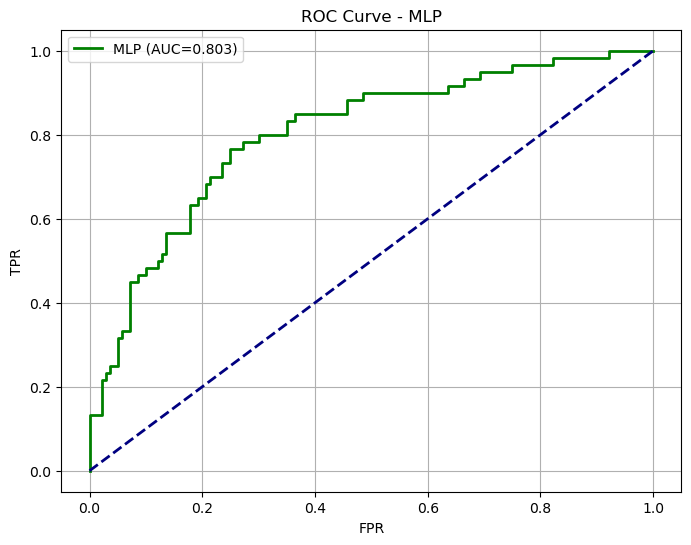

In [49]:
# ============ MODÈLE 3: DEEP LEARNING (MLP) ============
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_mlp = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_mlp.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("=" * 60)
print("DEEP LEARNING (MLP)")
print("=" * 60)

history = model_mlp.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

y_proba_mlp = model_mlp.predict(X_test_scaled, verbose=0).flatten()
y_pred_mlp = (y_proba_mlp > 0.5).astype(int)

auc_mlp = roc_auc_score(y_test, y_proba_mlp)
print(f"AUC: {auc_mlp:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_mlp, target_names=["Good", "Bad"]))

# Coût métier
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_mlp).ravel()
cost_mlp = 5 * fn + 1 * fp
print(f"Coût métier: {cost_mlp}")

# ROC Curve
fpr_mlp, tpr_mlp, _ = roc_curve(y_test, y_proba_mlp)
plt.figure(figsize=(8, 6))
plt.plot(fpr_mlp, tpr_mlp, color='green', lw=2, label=f'MLP (AUC={auc_mlp:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC Curve - MLP')
plt.legend()
plt.grid(True)
plt.show()

RÉSUMÉ DES MODÈLES
             Modèle      AUC  Coût Métier
Logistic Regression 0.809762          155
            XGBoost 0.799048          151
                MLP 0.803333          152


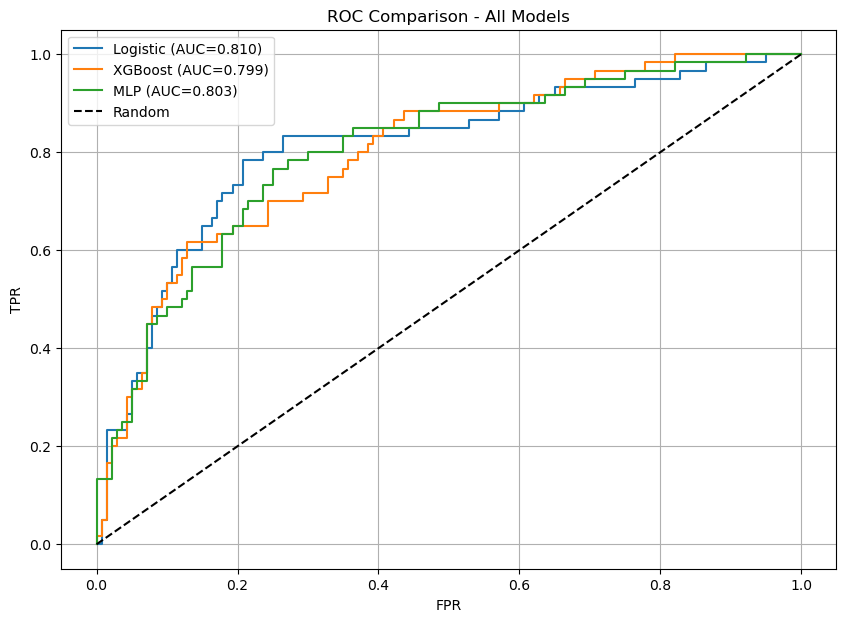

In [50]:
# ============ COMPARAISON DES MODÈLES ============
print("=" * 60)
print("RÉSUMÉ DES MODÈLES")
print("=" * 60)

# Logistic Regression
y_proba_lr = result_lr.predict(X_test_lr)
auc_lr = roc_auc_score(y_test, y_proba_lr)
y_pred_lr = (y_proba_lr > 0.5).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_lr).ravel()
cost_lr = 5 * fn + 1 * fp

# Calcul de la courbe ROC pour Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)

# Résumé
models_comparison = pd.DataFrame({
    'Modèle': ['Logistic Regression', 'XGBoost', 'MLP'],
    'AUC': [auc_lr, auc_xgb, auc_mlp],
    'Coût Métier': [cost_lr, cost_xgb, cost_mlp]
})

print(models_comparison.to_string(index=False))

# Courbes ROC comparées
plt.figure(figsize=(10, 7))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic (AUC={auc_lr:.3f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC={auc_xgb:.3f})')
plt.plot(fpr_mlp, tpr_mlp, label=f'MLP (AUC={auc_mlp:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC Comparison - All Models')
plt.legend()
plt.grid(True)
plt.show()

Seuil optimal par coût métier :
  Logistic Regression : seuil = 0.280, coût = 91
  XGBoost             : seuil = 0.150, coût = 96
  MLP                : seuil = 0.220, coût = 96


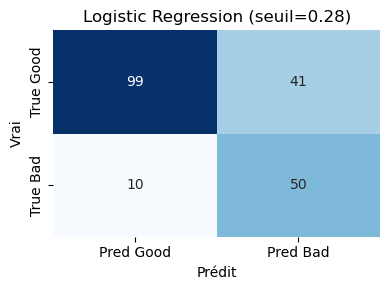

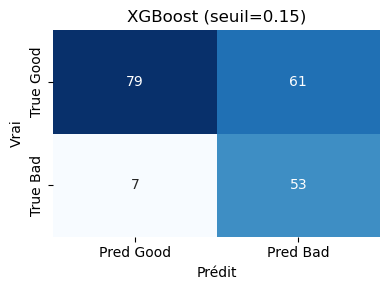

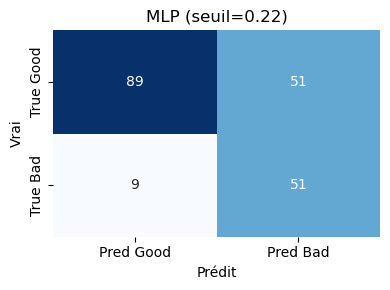

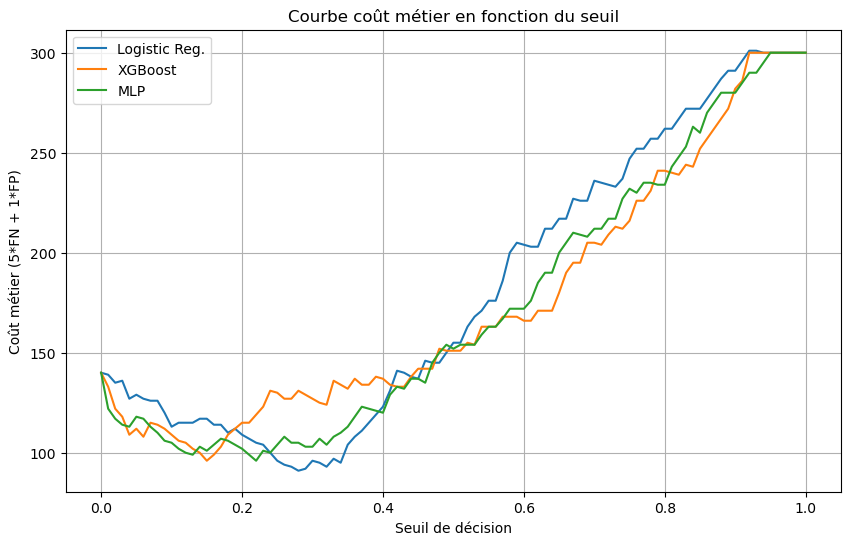

In [51]:
# ============ OPTIMISATION DU SEUIL PAR COÛT MÉTIER ============

def compute_business_cost_curve(y_true, y_proba, fn_cost=5, fp_cost=1, n_points=101):
    """Calcule le coût métier pour une grille de seuils entre 0 et 1."""
    thresholds = np.linspace(0.0, 1.0, n_points)
    costs = []
    for t in thresholds:
        y_hat = (y_proba >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_hat).ravel()
        cost = fn_cost * fn + fp_cost * fp
        costs.append(cost)
    return pd.DataFrame({"threshold": thresholds, "cost": costs})

# Courbes de coût pour les trois modèles
cost_lr_curve  = compute_business_cost_curve(y_test, y_proba_lr)
cost_xgb_curve = compute_business_cost_curve(y_test, y_proba_xgb)
cost_mlp_curve = compute_business_cost_curve(y_test, y_proba_mlp)

best_lr  = cost_lr_curve.loc[cost_lr_curve["cost"].idxmin()]
best_xgb = cost_xgb_curve.loc[cost_xgb_curve["cost"].idxmin()]
best_mlp = cost_mlp_curve.loc[cost_mlp_curve["cost"].idxmin()]

print("Seuil optimal par coût métier :")
print(f"  Logistic Regression : seuil = {best_lr.threshold:.3f}, coût = {best_lr.cost:.0f}")
print(f"  XGBoost             : seuil = {best_xgb.threshold:.3f}, coût = {best_xgb.cost:.0f}")
print(f"  MLP                : seuil = {best_mlp.threshold:.3f}, coût = {best_mlp.cost:.0f}")

# ============ MATRICES DE CONFUSION AUX SEUILS OPTIMAUX ============

def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Pred Good', 'Pred Bad'],
                yticklabels=['True Good', 'True Bad'])
    plt.title(title)
    plt.ylabel('Vrai')
    plt.xlabel('Prédit')
    plt.tight_layout()
    plt.show()

# Prédictions aux seuils optimaux (coût métier minimal)
y_opt_lr  = (y_proba_lr  >= best_lr.threshold).astype(int)
y_opt_xgb = (y_proba_xgb >= best_xgb.threshold).astype(int)
y_opt_mlp = (y_proba_mlp >= best_mlp.threshold).astype(int)

plot_conf_matrix(y_test, y_opt_lr,  f"Logistic Regression (seuil={best_lr.threshold:.2f})")
plot_conf_matrix(y_test, y_opt_xgb, f"XGBoost (seuil={best_xgb.threshold:.2f})")
plot_conf_matrix(y_test, y_opt_mlp, f"MLP (seuil={best_mlp.threshold:.2f})")

# Visualisation des courbes de coût
plt.figure(figsize=(10, 6))
plt.plot(cost_lr_curve["threshold"], cost_lr_curve["cost"], label="Logistic Reg.")
plt.plot(cost_xgb_curve["threshold"], cost_xgb_curve["cost"], label="XGBoost")
plt.plot(cost_mlp_curve["threshold"], cost_mlp_curve["cost"], label="MLP")
plt.xlabel("Seuil de décision")
plt.ylabel("Coût métier (5*FN + 1*FP)")
plt.title("Courbe coût métier en fonction du seuil")
plt.legend()
plt.grid(True)
plt.show()

Top 10 variables importantes (XGBoost) :
checking_account_status_risk     0.163736
savings_account_bonds_risk       0.070034
credit_history_risk              0.060778
other_installment_plans_risk     0.060345
property_risk                    0.057824
duration_months                  0.055215
purpose_risk                     0.054544
people_liable_maintenance        0.049084
other_debtors_guarantors_risk    0.046200
present_employment_since_risk    0.041741
dtype: float32


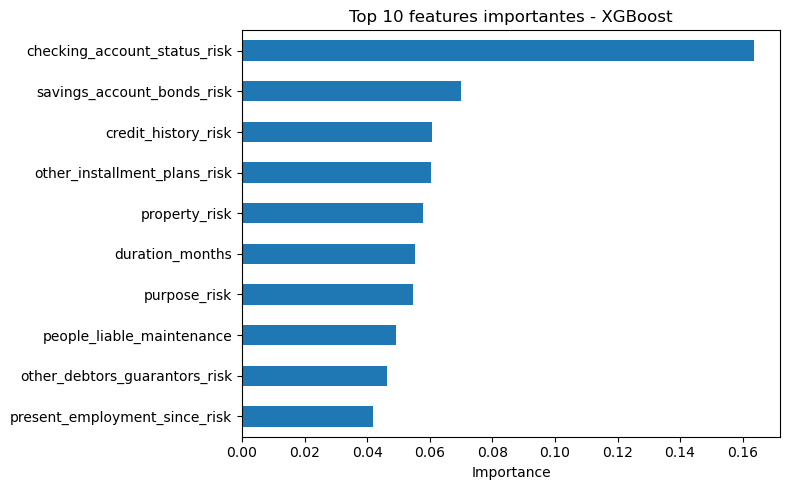


Variables significatives (Logit, p < 0.05) :
                                    coef        pvalue    odds_ratio
checking_account_status_risk    4.255446  8.447030e-11  7.048825e+01
const                         -17.717268  9.217081e-10  2.020636e-08
savings_account_bonds_risk      4.733856  5.026883e-05  1.137332e+02
purpose_risk                    4.703390  5.874569e-05  1.103205e+02
installment_rate_pct            0.339098  2.936223e-04  1.403681e+00
credit_history_risk             3.217735  3.420290e-04  2.497150e+01
personal_status_sex_risk        6.013585  1.539153e-03  4.089466e+02
other_installment_plans_risk    3.992178  2.898940e-03  5.417274e+01
present_employment_since_risk   2.983901  1.386718e-02  1.976477e+01
duration_months                 0.023425  2.327425e-02  1.023701e+00
foreign_worker_risk             6.507877  3.981388e-02  6.704017e+02


In [52]:
# ============ INTERPRÉTABILITÉ : IMPORTANCE DES VARIABLES ============

# XGBoost : importance des features
xgb_importances = pd.Series(model_xgb.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("Top 10 variables importantes (XGBoost) :")
print(xgb_importances.head(10))

plt.figure(figsize=(8, 5))
xgb_importances.head(10).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Top 10 features importantes - XGBoost')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

# Logistic regression (statsmodels) : coefficients significatifs
logit_summary = pd.DataFrame({
    'coef': result_lr.params,
    'pvalue': result_lr.pvalues
})
logit_summary['odds_ratio'] = np.exp(logit_summary['coef'])
logit_signif = logit_summary[logit_summary['pvalue'] < 0.05].sort_values('pvalue')

print("\nVariables significatives (Logit, p < 0.05) :")
print(logit_signif)
